<a href="https://colab.research.google.com/github/liminalvoid/nlp/blob/main/sem_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар 2. Domain Shift, наивный Байес, метрики

## Domain Shift/распределения

### Исходные датасеты

В качестве исходных датасетов используются `data-silence/rus_news_classifier` для классификации новостных текстов и `Kostya165/ru_emotion_dvach` для классификации эмоционального интента.

In [12]:
from datasets import load_dataset


rus_news_ds = load_dataset("data-silence/rus_news_classifier")
ru_emotion_ds = load_dataset("Kostya165/ru_emotion_dvach")

rus_news_ds, ru_emotion_ds

(DatasetDict({
     train: Dataset({
         features: ['news', 'labels'],
         num_rows: 57530
     })
     test: Dataset({
         features: ['news', 'labels'],
         num_rows: 14383
     })
 }),
 DatasetDict({
     train: Dataset({
         features: ['text', 'label'],
         num_rows: 59061
     })
     validation: Dataset({
         features: ['text', 'label'],
         num_rows: 2507
     })
 }))

### Топ-30 log-odds токенов

Извлечение подвыборок из каждого датасета размером 3000 строк.

In [13]:
import numpy as np


def sample_tests(ds, split, n=2000, text_key="text"):
    idx = np.random.choice(len(ds[split]), size=min(n, len(ds[split])), replace=False)

    return [ds[split][int(i)][text_key] for i in idx]


rus_news_train = sample_tests(rus_news_ds, "train", n=3000, text_key="news")
emotion_train = sample_tests(ru_emotion_ds, "train", n=3000)

print("rus_news sampled:", len(rus_news_train))
print("emotion sampled:", len(emotion_train))

rus_news sampled: 3000
emotion sampled: 3000


Вспомогательные функции для калькуляции log-odds.

In [14]:
import re
import math

from collections import Counter
from typing import List


TOKEN_RE = re.compile(r"[А-Яа-яЁё]+(?:-[А-Яа-яЁё]+)?")
simple_tokenize = lambda text, regex: regex.findall(text.lower())


def log_odds_with_smoothing(counts_a: Counter, counts_b: Counter, alpha: float = 0.1):
    """Δ(w)=log((c_a(w)+α)/(N_a+α|V|)) - log((c_b(w)+α)/(N_b+α|V|))"""
    vocab = set(counts_a) | set(counts_b)
    V = len(vocab)
    Na = sum(counts_a.values())
    Nb = sum(counts_b.values())
    deltas = {}

    for w in vocab:
        pa = (counts_a[w] + alpha) / (Na + alpha * V)
        pb = (counts_b[w] + alpha) / (Nb + alpha * V)
        deltas[w] = math.log(pa) - math.log(pb)

    return deltas


def get_tokens(texts, regex=TOKEN_RE):
    for t in texts:
        if t:
            yield from simple_tokenize(t, regex)


def top_log_odds_words(
        texts_a: Counter,
        texts_b: Counter,
        top_n: int = 25,
        alpha: float = 0.1
):
    """
    Функция для калькуляции log-odds для токенов.
    """
    deltas = log_odds_with_smoothing(texts_a, texts_b, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]

    return pos, neg

Log-odds для подвыборок.

In [15]:
import pandas as pd


rus_news_cnt = Counter(get_tokens(rus_news_train))
ru_emotion_cnt = Counter(get_tokens(emotion_train))
pos, neg = top_log_odds_words(rus_news_cnt, ru_emotion_cnt, top_n=30)

rus_news_vs_emotions = pd.DataFrame(pos, columns=["word", "∆(rus_news - emotion)"])
emotions_vs_rus_news = pd.DataFrame(neg, columns=["word", "∆(emotion - rus_news)"])

print("Топ-слова для rus_news (против emotion):")
display(rus_news_vs_emotions)

print("Топ-слова для emotion (против rus_news):")
display(emotions_vs_rus_news)

Топ-слова для rus_news (против emotion):


,word,∆(rus_news - emotion)
0,сообщает,7.317497
1,процента,6.746109
2,отметил,6.565765
3,сообщалось,6.455251
4,ру,6.178844
5,ссылкой,6.168520
6,сообщил,6.154587
7,издание,6.154587
8,рассказала,6.085620
9,января,6.066651


Топ-слова для emotion (против rus_news):


,word,∆(emotion - rus_news)
0,бред,-7.819431
1,идиоты,-7.689716
2,идиот,-7.661624
3,издевательство,-7.439192
4,серьёзным,-7.199000
5,знаешь,-7.104143
6,хохлы,-6.882242
7,сломается,-6.882242
8,пикабу,-6.882242
9,справлюсь,-6.749598


### Графики распределений

Увеличение размера графиков.

In [16]:
import matplotlib.pyplot as plt


plt.rcParams["figure.dpi"] = 140

#### Распределение длины документов

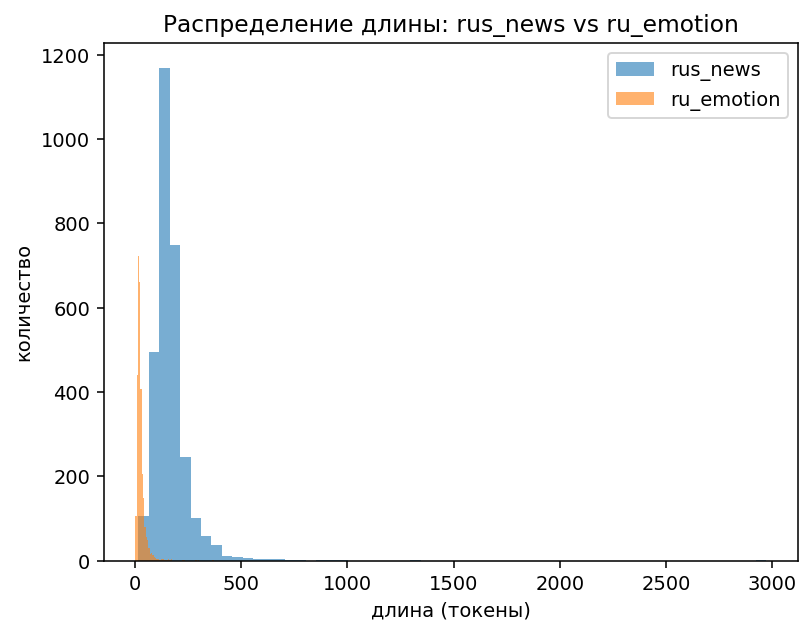

In [17]:
plt.figure()
plt.hist(
    [len(simple_tokenize(t, TOKEN_RE)) for t in rus_news_train if t],
    bins=60,
    alpha=0.6,
    label="rus_news",
)
plt.hist(
    [len(simple_tokenize(t, TOKEN_RE)) for t in emotion_train if t],
    bins=60,
    alpha=0.6,
    label="ru_emotion",
)
plt.legend()
plt.title("Распределение длины: rus_news vs ru_emotion")
plt.xlabel("длина (токены)")
plt.ylabel("количество")
plt.show()

#### Закон Ципфа (частоты топ-100 токенов)

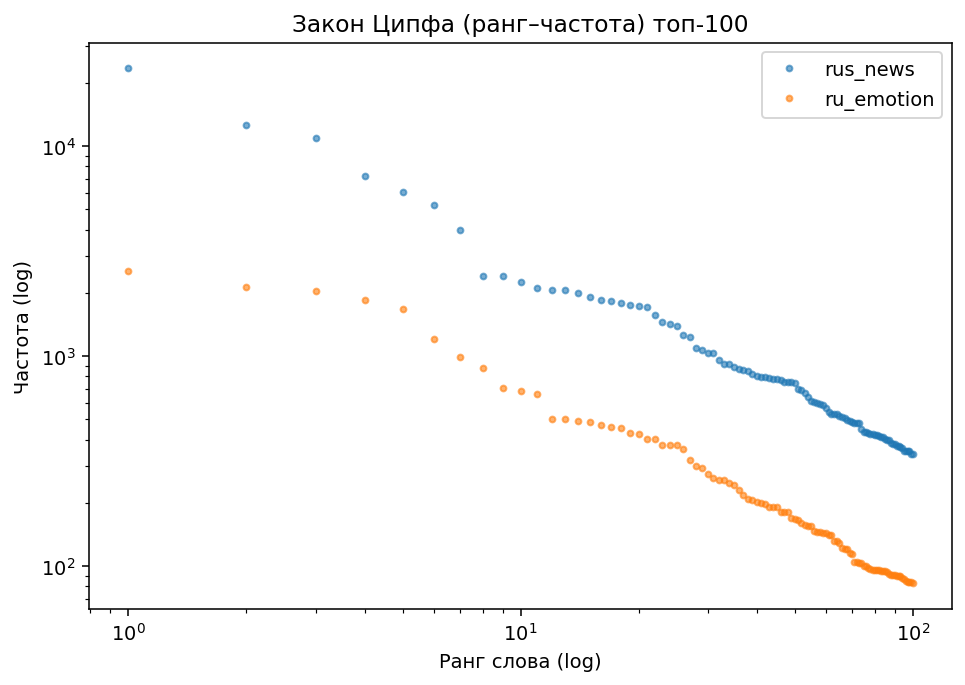

In [18]:
news_freqs_sorted = np.array([v for _, v in rus_news_cnt.most_common(100)])
news_ranks = np.arange(1, len(news_freqs_sorted) + 1)

emotion_freqs_sorted = np.array([v for _, v in ru_emotion_cnt.most_common(100)])
emotion_ranks = np.arange(1, len(emotion_freqs_sorted) + 1)

# 3.1 Zipf log-log
plt.figure(figsize=(7,5))
# news
plt.loglog(
    news_ranks,
    news_freqs_sorted,
    marker=".",
    linestyle="none",
    label="rus_news",
    alpha=0.6,
)
# emotion
plt.loglog(
    emotion_ranks,
    emotion_freqs_sorted,
    marker=".",
    linestyle="none",
    label="ru_emotion",
    alpha=0.6,
)
plt.legend()
plt.title("Закон Ципфа (ранг–частота) топ-100")
plt.xlabel("Ранг слова (log)")
plt.ylabel("Частота (log)")
plt.tight_layout()
plt.show()

#### Доля чисел/пунктуации

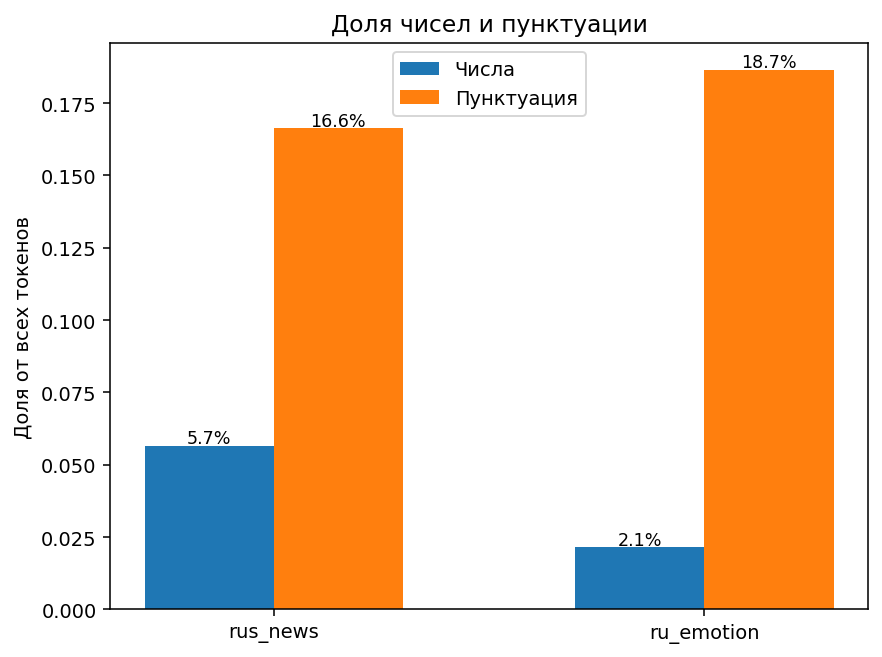

In [19]:
PUNCTUATION_REGEX = re.compile(r"[^\w\s]+")
DIGIT_REGEX = re.compile(r"\d")

rus_news_punctuation_tokens = Counter(get_tokens(rus_news_train, regex=PUNCTUATION_REGEX))
rus_news_digit_tokens = Counter(get_tokens(rus_news_train, regex=DIGIT_REGEX))

emotion_punctuation_tokens = Counter(get_tokens(emotion_train, regex=PUNCTUATION_REGEX))
emotion_digit_tokens = Counter(get_tokens(emotion_train, regex=DIGIT_REGEX))

rus_news_total_tokens = rus_news_cnt.total() + rus_news_digit_tokens.total() + rus_news_punctuation_tokens.total()
emotion_total_tokens = ru_emotion_cnt.total() + emotion_digit_tokens.total() + emotion_punctuation_tokens.total()

news_num = rus_news_digit_tokens.total() / rus_news_total_tokens
news_punct = rus_news_punctuation_tokens.total() / rus_news_total_tokens
emotion_num = emotion_digit_tokens.total() / emotion_total_tokens
emotion_punct = emotion_punctuation_tokens.total() / emotion_total_tokens

labels = ["rus_news", "ru_emotion"]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots()
ax.bar(
    x - width/2,
    [news_num, emotion_num],
    width,
    label="Числа",
)
ax.bar(
    x + width/2,
    [news_punct, emotion_punct],
    width,
    label="Пунктуация",
)
for i, (n, p) in enumerate(zip([news_num, emotion_num], [news_punct, emotion_punct])):
    ax.text(i - width/2, n + 0.001, f"{n:.1%}", ha='center', fontsize=9)
    ax.text(i + width/2, p + 0.001, f"{p:.1%}", ha='center', fontsize=9)
ax.set_ylabel("Доля от всех токенов")
ax.set_title("Доля чисел и пунктуации")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

#### Размер словаря

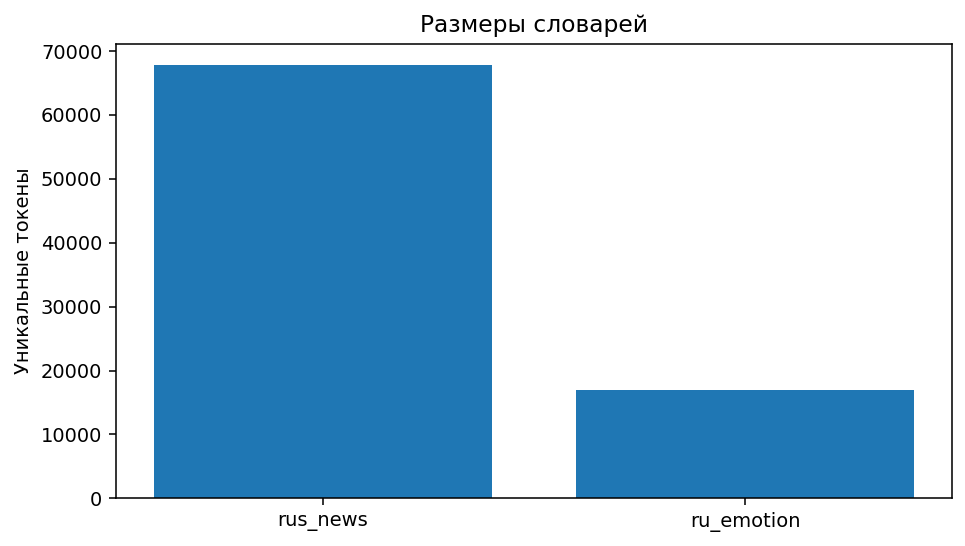

In [20]:
x = np.arange(2)

rus_news_dict_size = len(rus_news_cnt)
emotion_dict_size = len(ru_emotion_cnt)

plt.figure(figsize=(7,4))
plt.bar(
    ["rus_news", "ru_emotion"],
    [rus_news_dict_size, emotion_dict_size],
)
plt.title("Размеры словарей")
plt.ylabel("Уникальные токены")
plt.tight_layout()
plt.show()

### Лемматизация, n-граммы и стоп-слова

#### Лемматизация

In [21]:
!pip -q install pymorphy3 pymorphy3-dicts-ru

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 99.6 MB/s eta 0:00:00


In [22]:
import pymorphy3


morph = pymorphy3.MorphAnalyzer()

rus_news_lemmas_cnt = Counter([morph.parse(w)[0].normal_form for w in get_tokens(rus_news_train)])
emotions_lemmas_cnt = Counter([morph.parse(w)[0].normal_form for w in get_tokens(emotion_train)])

Сравнение после лемматизации.

In [23]:
pos, neg = top_log_odds_words(rus_news_lemmas_cnt, emotions_lemmas_cnt, top_n=30)

rus_news_vs_emotion_lemmas = pd.DataFrame(pos, columns=["word (after lemmatization)", "∆(rus_news - emotion)"])
emotion_vs_rus_news_lemmas = pd.DataFrame(neg, columns=["word (after lemmatization)", "∆(emotion - rus_news)"])

print("Топ-слова для rus_news (против emotion):")
display(rus_news_vs_emotion_lemmas)

print("Топ-слова для emotion (против rus_news):")
display(emotion_vs_rus_news_lemmas)

Топ-слова для rus_news (против emotion):


,word (after lemmatization),∆(rus_news - emotion)
0,отметить,7.228605
1,сообщаться,6.826059
2,издание,6.707869
3,коронавирус,6.510025
4,подчеркнуть,6.330100
5,январь,6.321616
6,ноябрь,6.175057
7,ру,6.134797
8,тасс,6.003269
9,агентство,5.896215


Топ-слова для emotion (против rus_news):


,word (after lemmatization),∆(emotion - rus_news)
0,бред,-7.910993
1,хохол,-7.518208
2,гениальный,-7.370338
3,пикаба,-6.926289
4,пидор,-6.862164
5,смотреть-ка,-6.862164
6,нахуй,-6.720082
7,хуйня,-6.720082
8,увлекательно,-6.640675
9,проститутка,-6.640675


#### Разбиение на n-граммы

In [24]:
import nltk


rus_news_bigrams = Counter(nltk.ngrams(get_tokens(rus_news_train), n=2))
rus_news_trigrams = Counter(nltk.ngrams(get_tokens(rus_news_train), n=3))

ru_emotion_bigrams = Counter(nltk.ngrams(get_tokens(emotion_train), n=2))
ru_emotion_trigrams = Counter(nltk.ngrams(get_tokens(emotion_train), n=3))

Сравнение после разбиения на биграммы.

In [25]:
pos, neg = top_log_odds_words(rus_news_bigrams, ru_emotion_bigrams, top_n=30)

rus_news_vs_emotion_bigrams = pd.DataFrame(pos, columns=["word (bigrams)", "∆(rus_news - emotion)"])
emotion_vs_rus_news_bigrams = pd.DataFrame(neg, columns=["word (bigrams)", "∆(emotion - rus_news)"])

print("Топ-слова для rus_news (против emotion):")
display(rus_news_vs_emotion_bigrams)

print("Топ-слова для emotion (против rus_news):")
display(emotion_vs_rus_news_bigrams)

Топ-слова для rus_news (против emotion):


,word (bigrams),∆(rus_news - emotion)
0,"(этом, сообщает)",7.245321
1,"(по, словам)",7.165291
2,"(сообщалось, что)",6.598008
3,"(стало, известно)",6.485290
4,"(ссылкой, на)",6.411703
5,"(со, ссылкой)",6.401235
6,"(ранее, в)",6.401235
7,"(отметил, что)",6.328502
8,"(ранее, сообщалось)",6.142477
9,"(на, процентов)",6.100727


Топ-слова для emotion (против rus_news):


,word (bigrams),∆(emotion - rus_news)
0,"(а, вдруг)",-8.368733
1,"(ну, конечно)",-8.312285
2,"(мог, подумать)",-8.227488
3,"(бы, мог)",-8.214765
4,"(ну, да)",-8.062959
5,"(ты, что)",-7.969287
6,"(о, конечно)",-7.865925
7,"(да, конечно)",-7.865925
8,"(подумать, что)",-7.665657
9,"(наверное, это)",-7.665657


Сравнение после разбиения на триграммы.

In [26]:
pos, neg = top_log_odds_words(rus_news_trigrams, ru_emotion_trigrams, top_n=30)

rus_news_vs_emotion_trigrams = pd.DataFrame(pos, columns=["word (trigrams)", "∆(rus_news - emotion)"])
emotion_vs_rus_news_trigrams = pd.DataFrame(neg, columns=["word (trigrams)", "∆(emotion - rus_news)"])

print("Топ-слова для rus_news (против emotion):")
display(rus_news_vs_emotion_trigrams)

print("Топ-слова для emotion (против rus_news):")
display(emotion_vs_rus_news_trigrams)

Топ-слова для rus_news (против emotion):


,word (trigrams),∆(rus_news - emotion)
0,"(об, этом, сообщает)",7.338410
1,"(со, ссылкой, на)",6.490811
2,"(ранее, сообщалось, что)",6.184297
3,"(стало, известно, что)",6.051517
4,"(об, этом, сообщается)",5.515247
5,"(материалы, по, теме)",5.496397
6,"(этом, сообщает, издание)",5.427472
7,"(об, этом, пишет)",5.385843
8,"(ранее, стало, известно)",5.375159
9,"(в, беседе, с)",5.308541


Топ-слова для emotion (против rus_news):


,word (trigrams),∆(emotion - rus_news)
0,"(кто, бы, мог)",-8.121676
1,"(бы, мог, подумать)",-8.121676
2,"(а, что, если)",-8.041740
3,"(ну, да, конечно)",-7.697470
4,"(мог, подумать, что)",-7.527209
5,"(уверен, что, это)",-7.455062
6,"(это, же, так)",-7.321887
7,"(но, что, если)",-7.232542
8,"(что, если, это)",-7.063219
9,"(что, будет, если)",-6.986554


#### Сравнение полученных важных токенов

In [27]:
print("Топ-слова для rus_news (против emotion):")
display(
    pd.concat(
        [
            rus_news_vs_emotions,
            rus_news_vs_emotion_lemmas,
            rus_news_vs_emotion_bigrams,
            rus_news_vs_emotion_trigrams,
        ],
        axis=1,
    )
)

print("Топ-слова для emotion (против rus_news):")
display(
    pd.concat(
        [
           emotions_vs_rus_news,
           emotion_vs_rus_news_lemmas,
           emotion_vs_rus_news_bigrams,
           emotion_vs_rus_news_trigrams,
        ],
        axis=1,
    )
)

Топ-слова для rus_news (против emotion):


,word,∆(rus_news - emotion),word (after lemmatization),∆(rus_news - emotion),word (bigrams),∆(rus_news - emotion),word (trigrams),∆(rus_news - emotion)
0,сообщает,7.317497,отметить,7.228605,"(этом, сообщает)",7.245321,"(об, этом, сообщает)",7.338410
1,процента,6.746109,сообщаться,6.826059,"(по, словам)",7.165291,"(со, ссылкой, на)",6.490811
2,отметил,6.565765,издание,6.707869,"(сообщалось, что)",6.598008,"(ранее, сообщалось, что)",6.184297
3,сообщалось,6.455251,коронавирус,6.510025,"(стало, известно)",6.485290,"(стало, известно, что)",6.051517
4,ру,6.178844,подчеркнуть,6.330100,"(ссылкой, на)",6.411703,"(об, этом, сообщается)",5.515247
5,ссылкой,6.168520,январь,6.321616,"(со, ссылкой)",6.401235,"(материалы, по, теме)",5.496397
6,сообщил,6.154587,ноябрь,6.175057,"(ранее, в)",6.401235,"(этом, сообщает, издание)",5.427472
7,издание,6.154587,ру,6.134797,"(отметил, что)",6.328502,"(об, этом, пишет)",5.385843
8,рассказала,6.085620,тасс,6.003269,"(ранее, сообщалось)",6.142477,"(ранее, стало, известно)",5.375159
9,января,6.066651,агентство,5.896215,"(на, процентов)",6.100727,"(в, беседе, с)",5.308541


Топ-слова для emotion (против rus_news):


,word,∆(emotion - rus_news),word (after lemmatization),∆(emotion - rus_news),word (bigrams),∆(emotion - rus_news),word (trigrams),∆(emotion - rus_news)
0,бред,-7.819431,бред,-7.910993,"(а, вдруг)",-8.368733,"(кто, бы, мог)",-8.121676
1,идиоты,-7.689716,хохол,-7.518208,"(ну, конечно)",-8.312285,"(бы, мог, подумать)",-8.121676
2,идиот,-7.661624,гениальный,-7.370338,"(мог, подумать)",-8.227488,"(а, что, если)",-8.041740
3,издевательство,-7.439192,пикаба,-6.926289,"(бы, мог)",-8.214765,"(ну, да, конечно)",-7.697470
4,серьёзным,-7.199000,пидор,-6.862164,"(ну, да)",-8.062959,"(мог, подумать, что)",-7.527209
5,знаешь,-7.104143,смотреть-ка,-6.862164,"(ты, что)",-7.969287,"(уверен, что, это)",-7.455062
6,хохлы,-6.882242,нахуй,-6.720082,"(о, конечно)",-7.865925,"(это, же, так)",-7.321887
7,сломается,-6.882242,хуйня,-6.720082,"(да, конечно)",-7.865925,"(но, что, если)",-7.232542
8,пикабу,-6.882242,увлекательно,-6.640675,"(подумать, что)",-7.665657,"(что, если, это)",-7.063219
9,справлюсь,-6.749598,проститутка,-6.640675,"(наверное, это)",-7.665657,"(что, будет, если)",-6.986554


## Наивный Баес, оценка

### Исходные данные

В качестве исходных данных использованы стихи и проза Булата Окуджавы и Александра Пушкина.

In [42]:
import requests

from io import BytesIO
from zipfile import ZipFile


def download_text(url: str, zip: bool = False) -> str:
    res = requests.get(url, timeout=30)

    if zip:
        zip_file = ZipFile(BytesIO(res.content))
        text = ""

        for line in zip_file.open(zip_file.namelist()[0]).readlines():
            text += line.decode("utf-8")

        return text

    if res.status_code == 200 and len(res.text) > 0:
        return res.text


pushkin_poetry_url = "https://samolit.com/downloads/download.php?book_id=93690&format=txt"
pushkin_prose_url = "https://samolit.com/downloads/download.php?book_id=59&format=txt"
gogol_poetry_url = "https://readli.net/download.php?id=130279"
gogol_prose_url = "https://samolit.com/downloads/download.php?book_id=114&format=txt"

pushkin_poetry = download_text(pushkin_poetry_url)
pushkin_prose = download_text(pushkin_prose_url)
gogol_poetry = download_text(gogol_poetry_url, zip=True)
gogol_prose = download_text(gogol_prose_url)

print("Количество символов")
print("Стихи Пушкина:", len(pushkin_poetry))
print("Стихи Гоголя:", len(gogol_poetry))
print("Проза Пушкина:", len(pushkin_prose))
print("Проза Гоголя:", len(gogol_prose))

Количество символов
Стихи Пушкина: 91278
Стихи Гоголя: 12290
Проза Пушкина: 226361
Проза Гоголя: 394268


### Разбиение текстов на чанки

In [45]:
def chunk_tokens(
    tokens: List[str],
    chunk_size: int = 250,
    min_frac: float = 0.5
) -> List[str]:
    """
    Режем токены на чанки фиксированной длины и сохраняем хвост,
    если он ≥ min_frac * chunk_size.
    """
    chunks = []
    min_len = int(chunk_size * min_frac)

    for i in range(0, len(tokens), chunk_size):
        chunk = tokens[i:i + chunk_size]

        if len(chunk) >= min_len:
            chunks.append(" ".join(chunk))

    return chunks


CHUNK_SIZE = 80

pushkin_prose_tokens = simple_tokenize(pushkin_prose, TOKEN_RE)
pushkin_prose_chunks = chunk_tokens(pushkin_prose_tokens, chunk_size=CHUNK_SIZE)
gogol_prose_tokens = simple_tokenize(gogol_prose, TOKEN_RE)
gogol_prose_chunks = chunk_tokens(gogol_prose_tokens, chunk_size=CHUNK_SIZE)

pushkin_poetry_tokens = simple_tokenize(pushkin_poetry, TOKEN_RE)
pushkin_poetry_chunks = chunk_tokens(pushkin_poetry_tokens, chunk_size=CHUNK_SIZE)
gogol_poetry_tokens = simple_tokenize(gogol_poetry, TOKEN_RE)
gogol_poetry_chunks = chunk_tokens(gogol_poetry_tokens, chunk_size=CHUNK_SIZE)

print("Чанки (проза):", len(pushkin_prose_chunks), len(gogol_prose_chunks))
print("Чанки (поэзия):", len(pushkin_poetry_chunks), len(gogol_poetry_chunks))

Чанки (проза): 434 783
Чанки (поэзия): 170 21


### Обучение MultinominalNB

Разбиение полученных чанков на train/valid.

In [46]:
from sklearn.model_selection import train_test_split


RANDOM_STATE = 42

# Метки: Pushkin = 0, Gogol = 1
X_prose = pushkin_prose_chunks + gogol_prose_chunks
y_prose = np.array([0] * len(pushkin_prose_chunks) + [1] * len(gogol_prose_chunks))

X_poetry = pushkin_poetry_chunks + gogol_poetry_chunks
y_poetry = np.array([0] * len(pushkin_poetry_chunks) + [1] * len(gogol_poetry_chunks))

author_names = ["Pushkin", "Gogol"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_prose,
    y_prose,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_prose,
)

print("Train chunks:", len(X_train), "Valid chunks:", len(X_valid))

Train chunks: 912 Valid chunks: 305


In [ ]:
from sklearn.pipeline import Pipeline


nb_counts_base = Pipeline([

])

### Топ-20 важнейших токенов

### Топ-20 важнейших токенов после лемматизации, n-грамм и стоп-слов

### Domain Shift